<a href="https://colab.research.google.com/github/oswram19/etl-proyecto-Soft02/blob/main/aduana1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import re

In [4]:
url ="https://raw.githubusercontent.com/oswram19/etl-proyecto-Soft02/refs/heads/main/Datos/ADUANA%20DATOS.csv"

df = pd.read_csv(url, sep=';')

df.head()

,EJERCICIO,MES,ADUANA1,ADUANA2,TIPO_OPERACION,SERIAL,CAPITULO,PARTIDA,SUBPARTIDA,PAIS,PREFERENCIA,PESO,CIF,FOB
0,2025,5,20,99999,1,4,32,3215,32151190,IL,NaN,42.82,4348.62,4343.26
1,2025,10,7,7,1,4,85,8512,85122000,TW,NaN,319.35,1370.93,1316.00
2,2025,8,9,9,1,4,85,8504,85049000,CN,NaN,12.53,1201.05,1201.05
3,2025,7,9,9,1,4,84,8484,84841000,TW,NaN,152.93,1533.08,1410.04
4,2025,3,76,99999,1,4,49,4908,49089000,BR,NaN,0.23,4.40,2.80


In [5]:
df.info()
print("\nValores nulos por columna:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455800 entries, 0 to 455799
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   EJERCICIO       455800 non-null  int64  
 1   MES             455800 non-null  int64  
 2   ADUANA1         455800 non-null  int64  
 3   ADUANA2         455800 non-null  int64  
 4   TIPO_OPERACION  455800 non-null  int64  
 5   SERIAL          455800 non-null  int64  
 6   CAPITULO        455800 non-null  int64  
 7   PARTIDA         455800 non-null  int64  
 8   SUBPARTIDA      455800 non-null  int64  
 9   PAIS            455800 non-null  object 
 10  PREFERENCIA     41549 non-null   object 
 11  PESO            451757 non-null  float64
 12  CIF             455800 non-null  float64
 13  FOB             455800 non-null  float64
dtypes: float64(3), int64(9), object(2)
memory usage: 48.7+ MB

Valores nulos por columna:
EJERCICIO              0
MES                    0
ADUANA1     

In [6]:
# Eliminamos la columna 'PREFERENCIA' debido al alto número de valores nulos.
df = df.drop('PREFERENCIA', axis=1)

# Rellenamos los valores nulos de la columna 'PESO' con la mediana.
median_peso = df['PESO'].median()
df['PESO'] = df['PESO'].fillna(median_peso)

print("Valores nulos después de la limpieza:")
print(df.isnull().sum())

Valores nulos después de la limpieza:
EJERCICIO         0
MES               0
ADUANA1           0
ADUANA2           0
TIPO_OPERACION    0
SERIAL            0
CAPITULO          0
PARTIDA           0
SUBPARTIDA        0
PAIS              0
PESO              0
CIF               0
FOB               0
dtype: int64


In [7]:
print(f"Número de filas duplicadas: {df.duplicated().sum()}")

Número de filas duplicadas: 6


In [8]:
df.drop_duplicates(inplace=True)
print(f"Número de filas después de eliminar duplicados: {len(df)}")

Número de filas después de eliminar duplicados: 455794


In [9]:
print("Valores únicos en la columna 'PAIS' y sus conteos:")
print(df['PAIS'].value_counts())

Valores únicos en la columna 'PAIS' y sus conteos:
PAIS
CN     119921
US      76784
MX      30401
GT      22741
DE      15630
        ...  
MS          1
MV          1
LY          1
TJ          1
VU          1
Name: count, Length: 197, dtype: int64


In [10]:
pais_counts = df['PAIS'].value_counts()
paises_a_agrupar = pais_counts[pais_counts < 500].index
df['PAIS'] = df['PAIS'].replace(paises_a_agrupar, 'Otros')

print("Valores únicos en la columna 'PAIS' y sus conteos después de agrupar:")
print(df['PAIS'].value_counts())

Valores únicos en la columna 'PAIS' y sus conteos después de agrupar:
PAIS
CN       119921
US        76784
MX        30401
GT        22741
DE        15630
JP        13125
IN        13013
ES        11772
IT        11576
CO        10961
TW        10824
BR        10308
KR         9796
Otros      6573
HN         5931
CR         5907
VN         5897
TH         5312
FR         4741
CA         4203
TR         3911
ID         3741
GB         3683
HK         3634
BD         2415
NL         2305
CH         2281
PA         2234
MY         2085
AR         2080
PL         2052
CL         1827
PE         1790
NI         1766
CZ         1746
TE         1723
KH         1625
BE         1602
PT         1396
SE         1341
AT         1321
PK         1196
EC         1142
DK         1013
SG          940
HU          922
IL          889
MA          874
PH          848
AU          788
RO          784
DO          749
SV          741
FI          670
IE          617
SK          585
AE          556
EG          5

In [11]:
print("Número de registros con PESO <= 0:", df[df['PESO'] <= 0].shape[0])
print("Número de registros con CIF <= 0:", df[df['CIF'] <= 0].shape[0])
print("Número de registros con FOB <= 0:", df[df['FOB'] <= 0].shape[0])

Número de registros con PESO <= 0: 382
Número de registros con CIF <= 0: 0
Número de registros con FOB <= 0: 0


In [12]:
df = df[df['PESO'] > 0]
print(f"Número de filas después de eliminar registros con PESO <= 0: {len(df)}")

Número de filas después de eliminar registros con PESO <= 0: 455412


In [13]:
df['FECHA'] = pd.to_datetime(df['EJERCICIO'].astype(str) + '-' + df['MES'].astype(str) + '-01')
print("Primeros 5 registros con la nueva columna 'FECHA':")
print(df[['EJERCICIO', 'MES', 'FECHA']].head())

Primeros 5 registros con la nueva columna 'FECHA':
   EJERCICIO  MES      FECHA
0       2025    5 2025-05-01
1       2025   10 2025-10-01
2       2025    8 2025-08-01
3       2025    7 2025-07-01
4       2025    3 2025-03-01


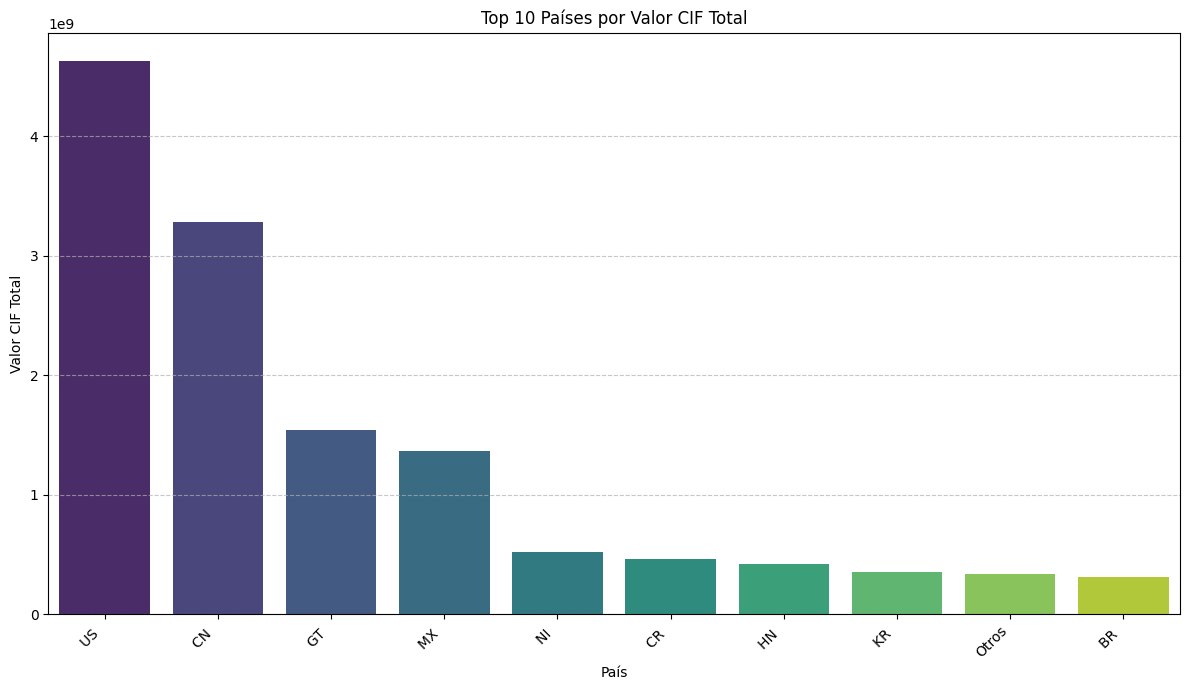

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'PAIS' and sum 'CIF' to get total CIF for each country
top_10_cif_paises = df.groupby('PAIS')['CIF'].sum().nlargest(10).reset_index()

# Create the bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x='PAIS', y='CIF', data=top_10_cif_paises, palette='viridis', hue='PAIS', legend=False)
plt.title('Top 10 Países por Valor CIF Total')
plt.xlabel('País')
plt.ylabel('Valor CIF Total')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [15]:
# Agrupar por mes (columna 'FECHA') y calcular el promedio de CIF y PESO
mensual_promedios = df.groupby(df['FECHA'].dt.to_period('M'))[['CIF', 'PESO']].mean().reset_index()

# Convertir 'FECHA' a un tipo de datos de marca de tiempo para una mejor visualización si es necesario
mensual_promedios['FECHA'] = mensual_promedios['FECHA'].dt.to_timestamp()

print("Promedio de CIF y PESO por mes:")
display(mensual_promedios.head())

Promedio de CIF y PESO por mes:


,FECHA,CIF,PESO
0,2025-01-01,35073.673579,27091.308555
1,2025-02-01,32288.109142,22526.274983
2,2025-03-01,36784.538626,27561.568328
3,2025-04-01,37108.928424,24569.395610
4,2025-05-01,38102.229822,28607.899833


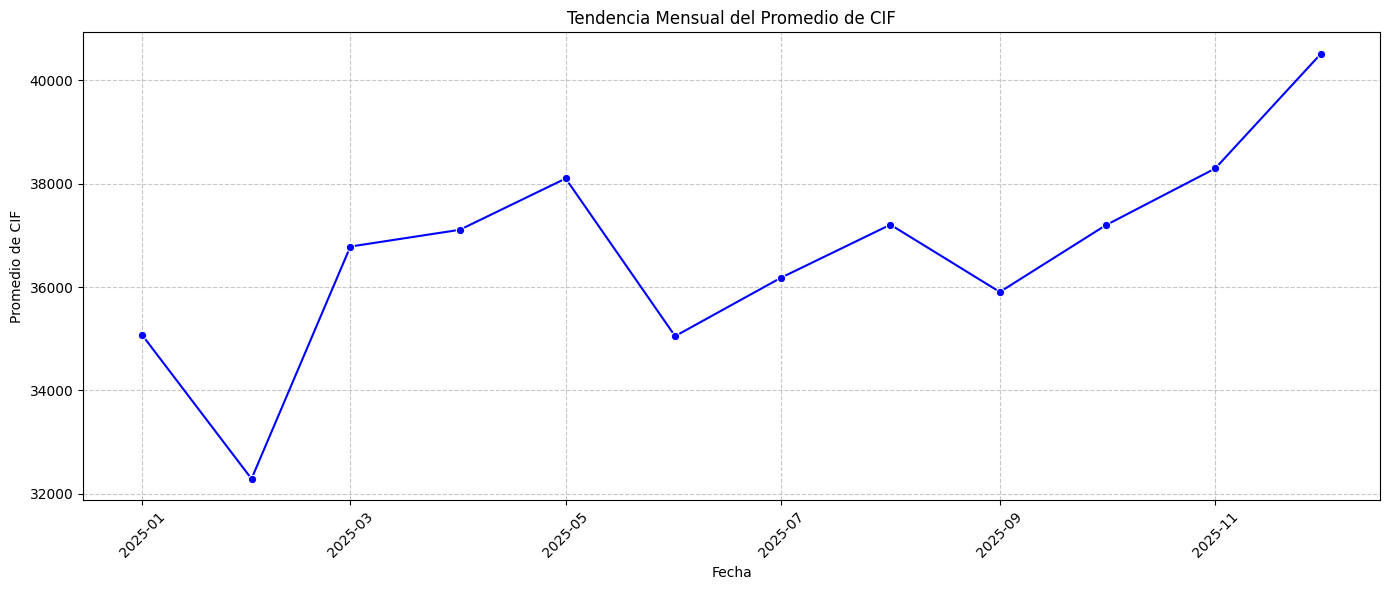

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

#  gráfico para la tendencia mensual del promedio de CIF
plt.figure(figsize=(14, 6))
sns.lineplot(x='FECHA', y='CIF', data=mensual_promedios, marker='o', color='blue')
plt.title('Tendencia Mensual del Promedio de CIF')
plt.xlabel('Fecha')
plt.ylabel('Promedio de CIF')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

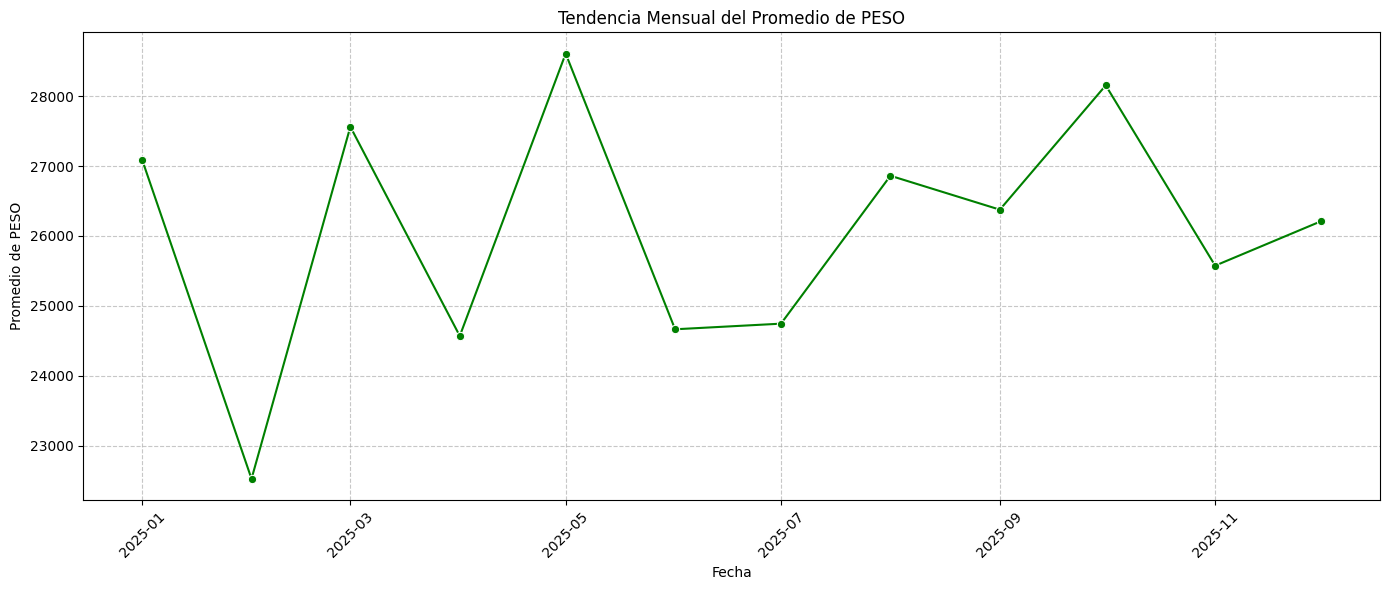

In [17]:
# gráfico para la tendencia mensual del promedio de PESO
plt.figure(figsize=(14, 6))
sns.lineplot(x='FECHA', y='PESO', data=mensual_promedios, marker='o', color='green')
plt.title('Tendencia Mensual del Promedio de PESO')
plt.xlabel('Fecha')
plt.ylabel('Promedio de PESO')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Análisis de Detección de Outliers (Valores Atípicos) en CIF

Vamos a utilizar el método del Rango Intercuartílico (IQR) para identificar valores atípicos en la columna `CIF`. El IQR es una medida de la dispersión estadística, siendo igual a la diferencia entre el tercer y el primer cuartil. Los valores atípicos se definen como aquellos que caen fuera de 1.5 veces el IQR por debajo del primer cuartil o por encima del tercer cuartil.

In [19]:
# Calcular Q1 (Primer Cuartil) y Q3 (Tercer Cuartil) para la columna 'CIF'
Q1_cif = df['CIF'].quantile(0.25)
Q3_cif = df['CIF'].quantile(0.75)

# Calcular el Rango Intercuartílico (IQR)
IQR_cif = Q3_cif - Q1_cif

# Definir los límites para la detección de outliers
lower_bound_cif = Q1_cif - 1.5 * IQR_cif
upper_bound_cif = Q3_cif + 1.5 * IQR_cif

print(f"Q1 (CIF): {Q1_cif:.2f}")
print(f"Q3 (CIF): {Q3_cif:.2f}")
print(f"IQR (CIF): {IQR_cif:.2f}")
print(f"Límite Inferior (Outliers CIF): {lower_bound_cif:.2f}")
print(f"Límite Superior (Outliers CIF): {upper_bound_cif:.2f}")

Q1 (CIF): 210.60
Q3 (CIF): 9079.08
IQR (CIF): 8868.48
Límite Inferior (Outliers CIF): -13092.12
Límite Superior (Outliers CIF): 22381.80


In [20]:
# Identificar outliers en la columna 'CIF'
outliers_cif = df[(df['CIF'] < lower_bound_cif) | (df['CIF'] > upper_bound_cif)]

print(f"Número de outliers detectados en 'CIF': {len(outliers_cif)}")
print("Primeros 5 outliers en 'CIF':")
display(outliers_cif.head())

Número de outliers detectados en 'CIF': 71261
Primeros 5 outliers en 'CIF':


,EJERCICIO,MES,ADUANA1,ADUANA2,TIPO_OPERACION,SERIAL,CAPITULO,PARTIDA,SUBPARTIDA,PAIS,PESO,CIF,FOB,FECHA
11,2025,9,5,5,1,4,39,3925,39252000,GT,82558.11,188342.48,182588.21,2025-09-01
15,2025,4,9,9,1,4,49,4901,49019900,CR,3611.90,55380.60,53896.89,2025-04-01
16,2025,7,7,7,1,4,96,9603,96039020,GT,35094.00,68563.43,66603.91,2025-07-01
20,2025,12,9,9,1,4,39,3921,39211990,PA,11023.90,70205.36,56505.36,2025-12-01
24,2025,7,5,5,1,4,84,8413,84133000,CN,8322.79,97954.34,93409.54,2025-07-01


Para visualizar la distribución de `CIF` y los outliers, podemos usar un diagrama de caja (boxplot).

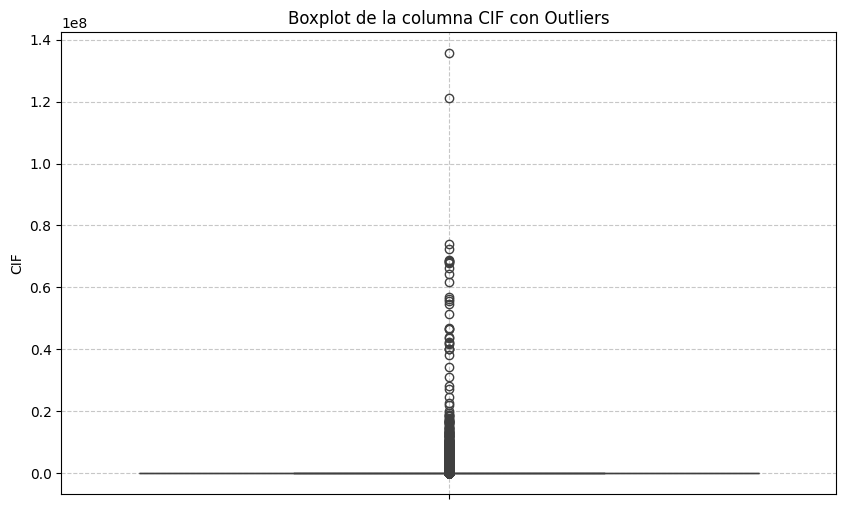

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['CIF'])
plt.title('Boxplot de la columna CIF con Outliers')
plt.ylabel('CIF')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [22]:
df.to_csv('aduana_datos_processed.csv', index=False)
print("DataFrame guardado en 'aduana_datos_processed.csv'")

DataFrame guardado en 'aduana_datos_processed.csv'
